In [167]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  # or thread_map
import umap
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon, cosine, minkowski
from scipy.special import softmax
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pyreadr import read_r
import multiprocessing as mp
from functools import partial
import random
from collections import defaultdict
import ipyvolume as ipv


t_threshold = 242
ts_df = pd.read_csv("./data/embryo2/tracks.txt", sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["name"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4]*0.1625
    valid_cell_names.append(name)

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

if   EMBRYO==1: TSTOP=250

elif EMBRYO==2: TSTOP=242

elif EMBRYO==3: TSTOP=221

In [169]:
# lineage_exp = read_r("./data/viscello/lin_sc_expr_190602.rds")[None]
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_raw_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_umap_embedding.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/binned_tenth_lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/binned_lineage_adj_exp_umap_embedding_3d.csv", index_col=0)
lineage_exp = pd.read_csv("data/protein/aggregated_all/binned_lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/lineage_umap_embedding_s3.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/s3.csv", index_col=0).T
binary_lineage_exp = pd.read_csv("./data/protein/aggregated_all/lineage_binary_expression.csv", index_col=0)
binary_lineage_end_exp = pd.read_csv("./data/protein/aggregated_all/lineage_end_binary_expression.csv", index_col=0)
# fill nan with 0
lineage_exp = lineage_exp.fillna(0)

In [170]:
# check number of positive values of each column
# lineage_exp_positive = lineage_exp.loc[:, (lineage_exp > 0).any(axis=0)]
# lineage_exp_positive_count = (lineage_exp_positive > 0).sum(axis=0)
# lineage_exp_positive_count.sort_values(ascending=True).head(20)

In [171]:
# tf filtering
# tf_df = pd.read_csv("./data/full_tf_names.tsv", sep="\t")
# tf_names = tf_df[~tf_df["Public name"].isna()]["Public name"].values
# tf_names_alt = tf_df["Sequence name"].values

In [172]:
# gene_name_df = pd.read_csv("./data/full_gene_names.tsv", sep="\t")
# valid_tf_names = []
# for name in gene_name_df['Gene'].values:
#     if name in tf_names or name in tf_names_alt:
#         valid_tf_names.append(name)

# # save to file for later use
# np.savetxt("./data/dropbox_valid_tf_names.txt", valid_tf_names, fmt="%s")


In [173]:
# expression data with only valid TFs
# lineage_exp = lineage_exp.loc[valid_tf_names]
lineage_names_with_exp = lineage_exp.columns.values
name_to_idx = {name: idx for idx, name in enumerate(lineage_exp.columns)}
expression_softmax = softmax(lineage_exp.values, axis=0)
lineage_softmax_exp = lineage_exp.copy()
lineage_softmax_exp.iloc[:,:] = expression_softmax

In [174]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_dict = defaultdict(str)
for lineage in lineage_exp.columns:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [175]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')


In [176]:
from collections import defaultdict
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    if len(children) == 0:
        lookup_name = map_names(node["did"])
        p_lookup_name = map_names(parent['did'])
        
        if lookup_name in valid_cell_names and lookup_name in lineage_names_with_exp and p_lookup_name in lineage_names_with_exp:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_ancestry[len(terminal_nodes)-1] = ancestors
    else:
        for child in children:
            dfs(child, node, ancestors + [node["did"]])

dfs(lineage_data, None)

In [177]:
def terminal_cousin_group(terminal_ancestry, degree=2):
    lowest_common_ancestor_group = defaultdict(list)
    for terminal_name, ancestry in terminal_ancestry.items():
        if len(ancestry) < degree:
            continue
        lca = ancestry[-degree]
        lowest_common_ancestor_group[lca].append(terminal_name)
    return lowest_common_ancestor_group

In [178]:
terminal_node_cords = []
terminal_parent_cords = []
xyz_coord_dict = {}
exp_vector_dict = {}
# Collect coordinates for terminal nodes and their parents

for node, parent in zip(terminal_nodes, terminal_parents):
    xyz_coord_dict[node] = ts_df.loc[ts_df['name'] == node].values[-1][1:4]*0.1625
    xyz_coord_dict[parent] = ts_df.loc[ts_df['name'] == parent].values[-1][1:4]*0.1625
    exp_vector_dict[node] = lineage_exp.loc[:, node].values
    exp_vector_dict[parent] = lineage_exp.loc[:, parent].values

In [179]:
class ParetoFront:
    def __init__(self, terminal_nodes, terminal_parents, terminal_ancestry, ts_df, lineage_exp, binary_lineage_exp, binary_lineage_end_exp, title="Pareto Front"):
        self.terminal_nodes = terminal_nodes
        self.terminal_parents = terminal_parents
        self.terminal_ancestry = terminal_ancestry
        self.title = title

        self.xyz_coord_dict = {}
        self.exp_vector_dict = {}
        self.binary_exp_vector_dict = {}
        self.binary_end_exp_vector_dict = {}
        for node, parent in zip(terminal_nodes, terminal_parents):
            self.xyz_coord_dict[node] = ts_df.loc[ts_df['name'] == node].values[-1][1:4]*0.1625
            self.xyz_coord_dict[parent] = ts_df.loc[ts_df['name'] == parent].values[-1][1:4]*0.1625
            self.exp_vector_dict[node] = lineage_exp.loc[:, node].values
            self.exp_vector_dict[parent] = lineage_exp.loc[:, parent].values
            self.binary_exp_vector_dict[node] = binary_lineage_exp.loc[:, node].values
            self.binary_exp_vector_dict[parent] = binary_lineage_exp.loc[:, parent].values
            self.binary_end_exp_vector_dict[node] = binary_lineage_end_exp.loc[:, node].values
            self.binary_end_exp_vector_dict[parent] = binary_lineage_end_exp.loc[:, parent].values

    def compute_cost_matrices(self, norm="l2"):
        """
        Compute cost matrices for xyz coordinates and expression vectors.
        
        :param norm: The norm to use for distance calculation. Options are "l2", "cosine", "l2+cosine".
        :return: Tuple of (xyz_cost_mat, exp_cost_mat).
        """
        xyz_cost_mat = np.zeros((len(self.terminal_parents), len(self.terminal_nodes)))
        exp_cost_mat = np.zeros((len(self.terminal_parents), len(self.terminal_nodes)))
        for i in tqdm(range(len(self.terminal_parents))):
            for j in range(len(self.terminal_nodes)):
                if norm == "l1":
                    xyz_cost_mat[i][j] = minkowski(self.xyz_coord_dict[self.terminal_parents[i]], self.xyz_coord_dict[self.terminal_nodes[j]], p=1)
                    exp_cost_mat[i][j] = minkowski(self.exp_vector_dict[self.terminal_parents[i]], self.exp_vector_dict[self.terminal_nodes[j]], p=1)
                elif norm == "l2":
                    xyz_cost_mat[i][j] = minkowski(self.xyz_coord_dict[self.terminal_parents[i]], self.xyz_coord_dict[self.terminal_nodes[j]], p=2)
                    exp_cost_mat[i][j] = minkowski(self.exp_vector_dict[self.terminal_parents[i]], self.exp_vector_dict[self.terminal_nodes[j]], p=2)
                elif norm == "cosine":
                    xyz_cost_mat[i][j] = cosine(self.xyz_coord_dict[self.terminal_parents[i]], self.xyz_coord_dict[self.terminal_nodes[j]])
                    exp_cost_mat[i][j] = cosine(self.exp_vector_dict[self.terminal_parents[i]], self.exp_vector_dict[self.terminal_nodes[j]])
                elif norm == "l2+cosine":
                    xyz_cost_mat[i][j] = minkowski(self.xyz_coord_dict[self.terminal_parents[i]], self.xyz_coord_dict[self.terminal_nodes[j]], p=2)
                    exp_cost_mat[i][j] = cosine(self.exp_vector_dict[self.terminal_parents[i]], self.exp_vector_dict[self.terminal_nodes[j]])
                elif norm == "l2+shannon":
                    xyz_cost_mat[i][j] = minkowski(self.xyz_coord_dict[self.terminal_parents[i]], self.xyz_coord_dict[self.terminal_nodes[j]], p=2)
                    exp_cost_mat[i][j] = jensenshannon(self.binary_exp_vector_dict[self.terminal_parents[i]], self.binary_exp_vector_dict[self.terminal_nodes[j]])
                elif norm == "l2+binary_state":
                    xyz_cost_mat[i][j] = minkowski(self.xyz_coord_dict[self.terminal_parents[i]], self.xyz_coord_dict[self.terminal_nodes[j]], p=2)
                    exp_cost_mat[i][j] = (~self.binary_end_exp_vector_dict[self.terminal_parents[i]] & self.binary_exp_vector_dict[self.terminal_nodes[j]]).sum()

        return xyz_cost_mat, exp_cost_mat

    def monte_carlo_simulation(self, xyz_cost_mat, exp_cost_mat, _):
        row_ind = range(len(xyz_cost_mat))
        random_permutation = np.random.permutation(len(row_ind))
        return xyz_cost_mat[row_ind, random_permutation].sum(), exp_cost_mat[row_ind, random_permutation].sum()

    def terminal_cousin_group(self, degree=2):
        lowest_common_ancestor_group = defaultdict(list)
        for terminal_name, ancestry in self.terminal_ancestry.items():
            if len(ancestry) < degree:
                continue
            lca = ancestry[-degree]
            lowest_common_ancestor_group[lca].append(terminal_name)
        self.cousin_group = lowest_common_ancestor_group
        return lowest_common_ancestor_group

    def compute_random_cost(self, xyz_cost_mat, exp_cost_mat, _):
        new_xyz_cost = 0
        new_exp_cost = 0
        for group in self.cousin_group.values():
            if len(group) < 2:
                new_xyz_cost += xyz_cost_mat[group, group]
                new_exp_cost += exp_cost_mat[group, group]
            else:
                shuffled_group = random.sample(group, len(group))
                new_xyz_cost += xyz_cost_mat[group, shuffled_group].sum()
                new_exp_cost += exp_cost_mat[group, shuffled_group].sum()
        return new_xyz_cost, new_exp_cost

    def compute_pareto_front(self, xyz_cost_mat, exp_cost_mat, monte_carlo=False, step_size=0.001):
        loop_len = int(1 / step_size) + 1
        if monte_carlo:
            repeat = 1000000
        else:
            repeat = 1000
        # multiprocessing to speed up monte carlo simulation
        monte_carlo_list = process_map(partial(self.monte_carlo_simulation, xyz_cost_mat, exp_cost_mat), range(repeat), max_workers=20, chunksize=100, desc="Monte Carlo Simulation")
        xyz_monte_carlo_mean = np.mean([x[0] for x in monte_carlo_list])
        exp_monte_carlo_mean = np.mean([x[1] for x in monte_carlo_list])
        xyz_monte_carlo_std = np.std([x[0] for x in monte_carlo_list])
        exp_monte_carlo_std = np.std([x[1] for x in monte_carlo_list])

        pareto_xyz_cost_list = []
        pareto_exp_cost_list = []
        pareto_xyz_dev_list = []
        pareto_exp_dev_list = []
        lineage_exp_cost = exp_cost_mat.diagonal().sum()
        lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
        lineage_exp_cost_dev = (lineage_exp_cost - exp_monte_carlo_mean) / (exp_monte_carlo_std + 1e-6)  # Avoid division by zero
        lineage_xyz_cost_dev = (lineage_xyz_cost - xyz_monte_carlo_mean) / (xyz_monte_carlo_std + 1e-6)  # Avoid division by zero
        for i in range(loop_len):
            alpha = 0 + step_size * i
            cur_cost_mat = alpha * xyz_cost_mat + (1 - alpha) * exp_cost_mat
            if monte_carlo:
                cur_cost_mat = alpha * (xyz_cost_mat/xyz_monte_carlo_std) + (1 - alpha) * (exp_cost_mat/exp_monte_carlo_std)
            cur_row_ind, cur_col_ind = linear_sum_assignment(cur_cost_mat)
            cur_xyz_cost = xyz_cost_mat[cur_row_ind, cur_col_ind].sum()
            cur_exp_cost = exp_cost_mat[cur_row_ind, cur_col_ind].sum()
            cur_xyz_cost_dev = (cur_xyz_cost - xyz_monte_carlo_mean) / xyz_monte_carlo_std
            cur_exp_cost_dev = (cur_exp_cost - exp_monte_carlo_mean) / exp_monte_carlo_std
            pareto_xyz_cost_list.append(cur_xyz_cost)
            pareto_exp_cost_list.append(cur_exp_cost)
            pareto_xyz_dev_list.append(cur_xyz_cost_dev)
            pareto_exp_dev_list.append(cur_exp_cost_dev)
        # normalize pareto cost lists to have a range of 0 to 1
        normalized_pareto_xyz_cost_list = (np.array(pareto_xyz_cost_list) - np.min(pareto_xyz_cost_list)) / (np.max(pareto_xyz_cost_list) - np.min(pareto_xyz_cost_list))
        normalized_pareto_exp_cost_list = (np.array(pareto_exp_cost_list) - np.min(pareto_exp_cost_list)) / (np.max(pareto_exp_cost_list) - np.min(pareto_exp_cost_list))
        normalized_lineage_xyz_cost = (lineage_xyz_cost - np.min(pareto_xyz_cost_list)) / (np.max(pareto_xyz_cost_list) - np.min(pareto_xyz_cost_list))
        normalized_lineage_exp_cost = (lineage_exp_cost - np.min(pareto_exp_cost_list)) / (np.max(pareto_exp_cost_list) - np.min(pareto_exp_cost_list))
        # find best alpha fit for to minimize distance to lineage costs in normalized space
        best_fit = 0
        min_distance = float('inf')
        min_xyz_distance = float('inf')
        for i in range(loop_len):
            alpha = 0 + step_size * i
            cur_distance = np.sqrt((normalized_pareto_xyz_cost_list[i] - normalized_lineage_xyz_cost) ** 2 + (normalized_pareto_exp_cost_list[i] - normalized_lineage_exp_cost) ** 2)
            if cur_distance < min_distance:
                min_distance = cur_distance
                min_xyz_distance = pareto_xyz_cost_list[i]
                best_fit = alpha
        print(min_xyz_distance)
        if monte_carlo:
            return best_fit, pareto_xyz_dev_list, pareto_exp_dev_list, lineage_xyz_cost_dev, lineage_exp_cost_dev
        else:
            return best_fit, pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost    
        
    def pareto_rescale(self, pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost):
        """
        Rescale the pareto cost lists and lineage costs to have a range of 0 to 1.
        """
        min_xyz = np.min(pareto_xyz_cost_list)
        max_xyz = np.max(pareto_xyz_cost_list)
        min_exp = np.min(pareto_exp_cost_list)
        max_exp = np.max(pareto_exp_cost_list)

        pareto_xyz_cost_list = (np.array(pareto_xyz_cost_list) - min_xyz) / (max_xyz - min_xyz)
        pareto_exp_cost_list = (np.array(pareto_exp_cost_list) - min_exp) / (max_exp - min_exp)
        
        lineage_xyz_cost = (lineage_xyz_cost - min_xyz) / (max_xyz - min_xyz)
        lineage_exp_cost = (lineage_exp_cost - min_exp) / (max_exp - min_exp)

        return pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost
    

    def plot_pareto_front(self, lineage_xyz_cost, lineage_exp_cost, 
                      pareto_xyz_cost_list, pareto_exp_cost_list, 
                      alpha, norm, rescale=False, color='blue'):
        plt.figure(figsize=(8, 6))
        if rescale:
            pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost = self.pareto_rescale(
                pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost
            )
        plt.plot(pareto_xyz_cost_list, pareto_exp_cost_list, marker='o', linestyle='-', color=color, markersize=3, label='Pareto Front')
        plt.xlabel('XYZ Cost')
        plt.ylabel('Expression Cost')
        plt.scatter(lineage_xyz_cost, lineage_exp_cost, marker="D", color=color, label='Lineage Cost')
        plt.title(f'{self.title} (alpha={alpha}, norm={norm})')
        plt.grid(True)
        plt.legend()
        plt.show()
        return plt.figure

    def plot_pareto_front_series(self, pareto_front_series):
        """
        Plot multiple pareto fronts in the same figure.
        Each entry in pareto_front_series should be a tuple of the form:
        (lineage_xyz_cost, lineage_exp_cost, pareto_xyz_cost_list, pareto_exp_cost_list, alpha, norm)
        """
        plt.figure(figsize=(8, 6))
        line_colors = sns.color_palette(n_colors=len(pareto_front_series))
        lineage_colors = sns.color_palette(n_colors=len(pareto_front_series))
        for pareto_entry, line_color, lineage_color in zip(pareto_front_series, line_colors, lineage_colors):
            # Unpack the pareto entry
            lineage_xyz_cost, lineage_exp_cost, pareto_xyz_cost_list, pareto_exp_cost_list, alpha, norm = pareto_entry
            # Rescale the axis to have a range of 0 to 1
            pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost = self.pareto_rescale(
                pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost
            )
            plt.plot(pareto_xyz_cost_list, pareto_exp_cost_list, marker='o', linestyle='-', color=line_color, markersize=3, label=f'{norm} norm')
            plt.scatter(lineage_xyz_cost, lineage_exp_cost, marker="D" ,color=lineage_color, label=f'{norm} norm lineage')
        plt.xlabel('XYZ Cost')
        plt.ylabel('Expression Cost')
        plt.title(f'{self.title}s for Different Norms')
        plt.grid(True)
        plt.legend()
        plt.show()

    def restricted_shuffle(self, norm="l2"):
        xyz_cost_mat, exp_cost_mat = self.compute_cost_matrices(norm=norm)
        self.terminal_cousin_group()
        # Use multiprocessing for speed up
        random_cost_list = process_map(
            partial(self.compute_random_cost, xyz_cost_mat, exp_cost_mat),
            range(100000), 
            max_workers=20, 
            chunksize=1000, 
            desc="Computing random costs"
        )

        # plotting the distribution of random costs in a 2d plot
        lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
        lineage_exp_cost = exp_cost_mat.diagonal().sum()
        alpha, pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost = self.compute_pareto_front(xyz_cost_mat, exp_cost_mat, monte_carlo=False)

        plt.figure(figsize=(8, 6))
        plt.plot(pareto_xyz_cost_list, pareto_exp_cost_list, marker='o', linestyle='-', color='blue', markersize=3, label='Pareto Front')
        plt.xlabel('XYZ Cost')
        plt.ylabel('Expression Cost')
        plt.scatter(lineage_xyz_cost, lineage_exp_cost, color='red', label='Lineage Cost')
        plt.scatter([x[0] for x in random_cost_list], [x[1] for x in random_cost_list], alpha=0.5, s=1, label='Random Cousin Shuffles')
        plt.title(f'{self.title} (alpha={alpha}, norm={norm})')
        plt.grid(True)
        plt.legend()
        plt.show()

    def normal_run(self):
        pareto_plot_series = []
        colors = sns.color_palette(n_colors=4)
        for norm, color in zip(["l1", "l2", "cosine", "l2+cosine"], colors):
            print(f"Computing cost matrices with norm: {norm}")
            xyz_cost_mat, exp_cost_mat = self.compute_cost_matrices(norm=norm)
            alpha, pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost = self.compute_pareto_front(xyz_cost_mat, exp_cost_mat, monte_carlo=False)
            self.plot_pareto_front(lineage_xyz_cost, lineage_exp_cost, pareto_xyz_cost_list, pareto_exp_cost_list, alpha, norm=norm, rescale=False, color=color)
            pareto_plot_series.append((lineage_xyz_cost, lineage_exp_cost, pareto_xyz_cost_list, pareto_exp_cost_list, alpha, norm))
            # print(f"Alpha: {alpha}")
        self.plot_pareto_front_series(pareto_plot_series)

    


In [180]:
new_pf = ParetoFront(terminal_nodes, terminal_parents, terminal_ancestry, ts_df, lineage_exp, binary_lineage_exp, binary_lineage_end_exp, title="t=242, Pareto Front of 248 Terminal Cells")

Computing cost matrices with norm: l1


100%|██████████| 248/248 [00:00<00:00, 325.94it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

950.4625000000001


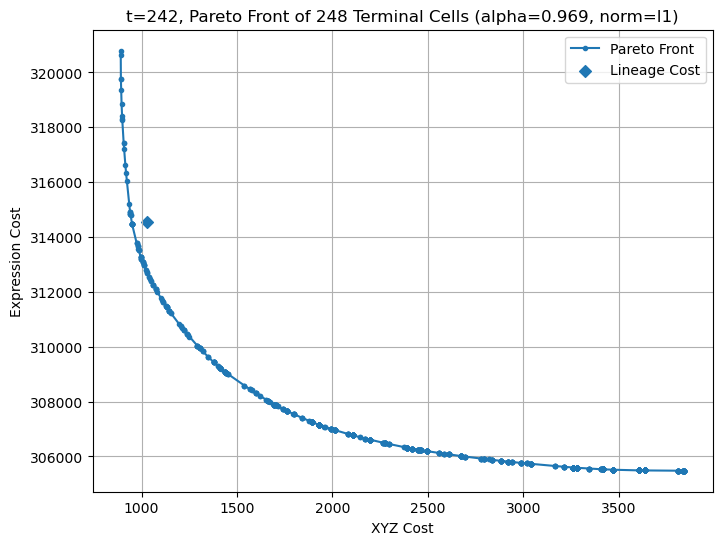

Computing cost matrices with norm: l2


100%|██████████| 248/248 [00:00<00:00, 408.43it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

633.6002680687883


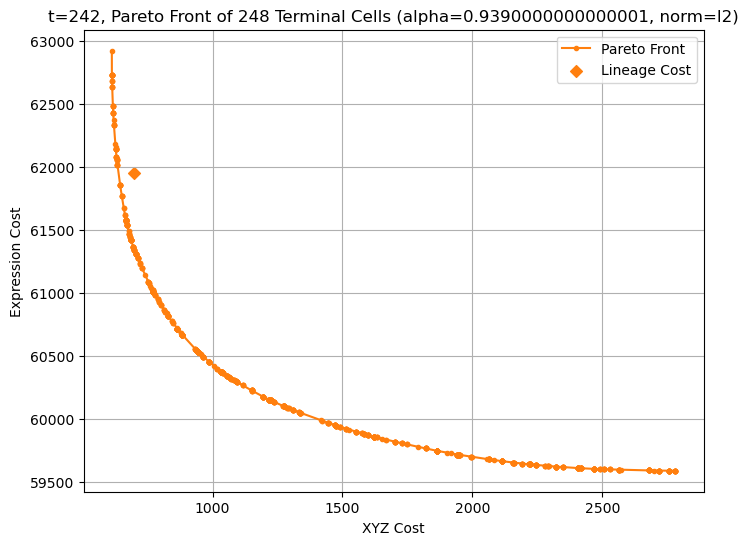

Computing cost matrices with norm: cosine


100%|██████████| 248/248 [00:00<00:00, 279.66it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

0.234885013741023


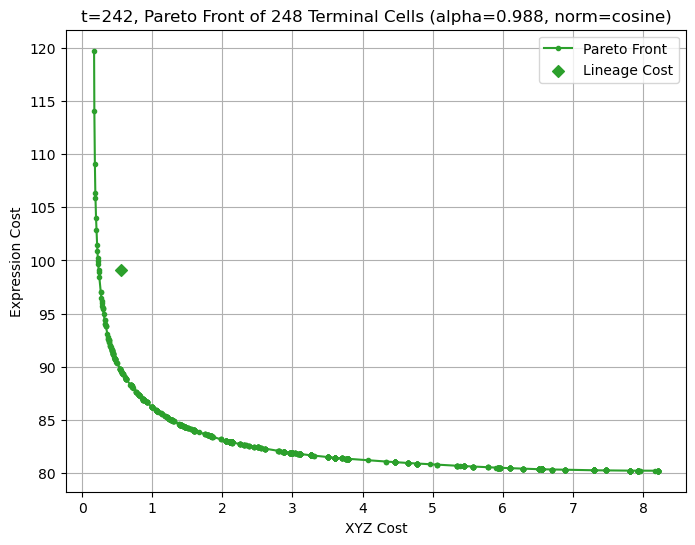

Computing cost matrices with norm: l2+cosine


100%|██████████| 248/248 [00:00<00:00, 344.07it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

646.477105189015


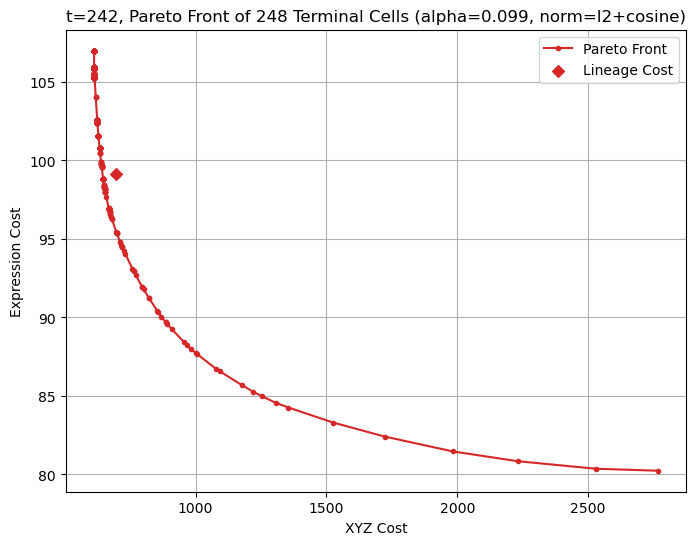

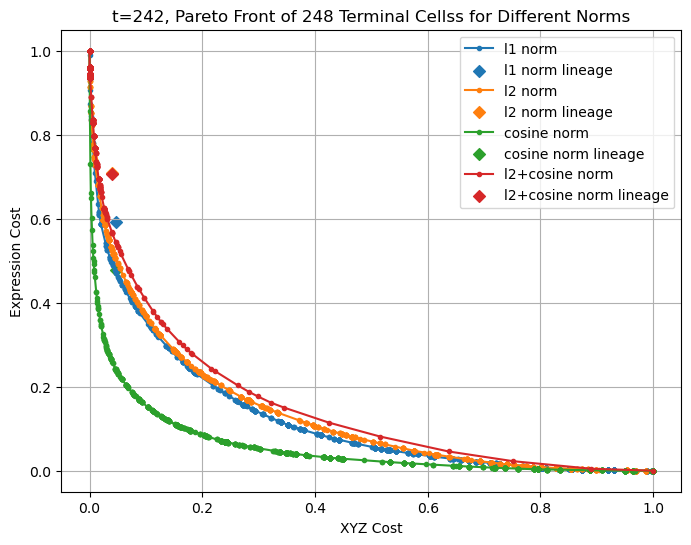

In [181]:
new_pf.normal_run()

In [112]:
sns.color_palette(n_colors=4)

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392)]

In [ ]:
def terminal_trajectory(terminal_node):
    ''' 
    using ipyvolume plot the lineage trajectory with directed arrow a terminal node in 3d plot
    the first few ancestors in each terminal's lineage may not have physical coordinates
    start from the first ancestor with physical coordinates
    '''
    if terminal_node not in terminal_nodes:
        print(f"Terminal node {terminal_node} not found in terminal nodes.")
        return
    ancestors = terminal_ancestry[terminal_nodes.index(terminal_node)]
    coordinates = []
    for ancestor in ancestors:
        if ancestor in all_xyz_map:
            coordinates.append(all_xyz_map[ancestor])
    if not coordinates:
        print(f"No physical coordinates found for ancestors of terminal node {terminal_node}.")
        return
    coordinates = np.array(coordinates)
    return coordinates

temp_coordinates = terminal_trajectory("ABprpppapaa").astype(float)
fig = ipv.figure()
x, y, z = temp_coordinates[:, 0], temp_coordinates[:, 1], temp_coordinates[:, 2]
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()
ipv.xlim(x_min, x_max)
ipv.ylim(y_min, y_max)
ipv.zlim(z_min, z_max)
dx = np.diff(temp_coordinates[:, 0])
dy = np.diff(temp_coordinates[:, 1])
dz = np.diff(temp_coordinates[:, 2])
ipv.quiver(temp_coordinates[:-1, 0], temp_coordinates[:-1, 1], temp_coordinates[:-1, 2], dx, dy, dz, 
          color='red', arrow_length_ratio=0.1, size=10)
ipv.plot(x, y, z, marker='o', linestyle='-', color='blue', size=2)
ipv.show()

In [ ]:
# for every terminal node, plot the trajectory
# save the plot to output/xyz_trajectories/{node_name}.png
import os
output_dir = "output/xyz_trajectories"
os.makedirs(output_dir, exist_ok=True)
for terminal_node in tqdm(terminal_nodes):
    fig = terminal_trajectory(terminal_node)
    if fig:
        fig.savefig(os.path.join(output_dir, f"{terminal_node}.png"))
        plt.close(fig)  # Close the figure to free memory


In [ ]:
pair_count = 0
diff_type_count = 0
for parent, children in terminal_parents_dict.items():
    if len(children) > 1:
        pair_count += 1
        type_0 = lineage_type_dict[children[0]]
        type_1 = lineage_type_dict[children[1]]
        if type_0 != type_1:
            diff_type_count += 1

for node in terminal_nodes:
    if len(lineage_type_dict[node]) == 0:
        print(f"Node {node} has no lineage type.")
            